In [216]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count
from environments import CorridorEnvTerminalReward
from utils import annotated_heatmap, analytical_policy_evaluation, epsilon_greedy_policy

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

In [281]:
class DQN(nn.Module):

    def __init__(self, n_observations, n_hidden, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, n_hidden)
        self.layer2 = nn.Linear(n_hidden, n_actions)

    # Called with either one element to determine next action, or a batch
    # during optimization.
    def forward(self, x):
        x = F.relu(self.layer1(x))
        return self.layer2(x)

In [449]:
env = CorridorEnvTerminalReward(n_states=10, is_slippery=False)

n_states = env.nS
n_actions = env.nA

possible_actions = np.linspace(0, env.nA-1, env.nA)
ALPHA = 1e-4
GAMMA = 0.95
BATCH_SIZE = 16
EPSILON = 0.01
N_EPISODES = 200
TAU = 0.01

n_hidden = 32

In [450]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [485]:
def deep_q_learning(epsilon: float = 0.1, gamma: float = 1.0, num_episodes: int = 10, exp_decay = True):
    err = []
    optimal_pi = [[0, 0, 1]] * n_states
    v_analytical = analytical_policy_evaluation(optimal_pi, env.model, gamma=gamma)

    policy_dqn = DQN(1, n_hidden, n_actions).to(device)
    target_dqn = DQN(1, n_hidden, n_actions).to(device)
    target_dqn.load_state_dict(policy_dqn.state_dict())
    
    optimizer = optim.AdamW(policy_dqn.parameters(), lr=ALPHA, amsgrad=True)
    memory = ReplayMemory(10000)

    for e in range(num_episodes):
        done = False
        # Initialize state as 2D: [1, 1]
        state_val = np.random.randint(0, env.nS)
        s = torch.tensor([[state_val]], dtype=torch.float32, device=device)

        while not done:
            with torch.no_grad():
                q_s = policy_dqn(s)

            # squeeze() turns [1, n_actions] into [n_actions] for the policy helper
            a = epsilon_greedy_policy(q_s.squeeze(), epsilon=epsilon)
            
            # Step the environment
            [_, s_next_val, r, done] = env.step(s.item(), a)[0]

            # Prepare tensors as 2D: [1, 1]
            # If done, we store s_next as None to trigger the non_final_mask logic
            a_tensor = torch.tensor([[a]], dtype=torch.int64, device=device)
            r_tensor = torch.tensor([[r]], dtype=torch.float32, device=device)
            
            if not done:
                s_next = torch.tensor([[s_next_val]], dtype=torch.float32, device=device)
            else:
                s_next = None

            memory.push(s, a_tensor, s_next, r_tensor)

            # Move to next state
            s = s_next if not done else s

            if len(memory) < BATCH_SIZE:
                if done: break # Don't get stuck in a loop if memory is small
                continue

            # --- Optimization Block ---
            transitions = memory.sample(BATCH_SIZE)
            batch = Transition(*zip(*transitions))

            # Mask for non-terminal states
            non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
            non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
            
            state_batch = torch.cat(batch.state)   # Shape: [Batch, 1]
            action_batch = torch.cat(batch.action) # Shape: [Batch, 1]
            reward_batch = torch.cat(batch.reward).squeeze() # Shape: [Batch]

            # Q(s, a)
            current_q_values = policy_dqn(state_batch).gather(1, action_batch)

            # Max Q(s', a') from Target Network
            next_q_values = torch.zeros(BATCH_SIZE, device=device)
            with torch.no_grad():
                if non_final_mask.any():
                    next_q_values[non_final_mask] = target_dqn(non_final_next_states).max(1)[0]

            # Bellman Equation
            expected_q_values = (next_q_values * gamma) + reward_batch

            # Loss (unsqueezing expected_q to [Batch, 1] to match current_q)
            criterion = nn.SmoothL1Loss()
            loss = criterion(current_q_values, expected_q_values.unsqueeze(1))

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_value_(policy_dqn.parameters(), 100)
            optimizer.step()

            # Soft update of target network
            target_dict = target_dqn.state_dict()
            policy_dict = policy_dqn.state_dict()
            for key in policy_dict:
                target_dict[key] = policy_dict[key] * TAU + target_dict[key] * (1 - TAU)
            target_dqn.load_state_dict(target_dict)
            
        # --- Value evaluation ---
        with torch.no_grad():
            v = []
            for state_idx in range(n_states):
                st = torch.tensor([[state_idx]], dtype=torch.float32, device=device)
                v.append(policy_dqn(st).max().item())
            err.append(sum((v_analytical - v)**2) / n_states)
            
    return v, err

In [486]:
v, err = deep_q_learning(epsilon=EPSILON, gamma=GAMMA, num_episodes=N_EPISODES)

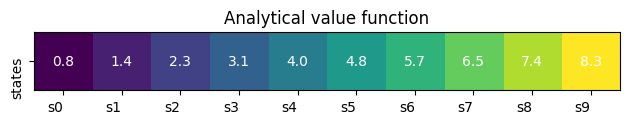

In [487]:
annotated_heatmap([v], "Analytical value function")

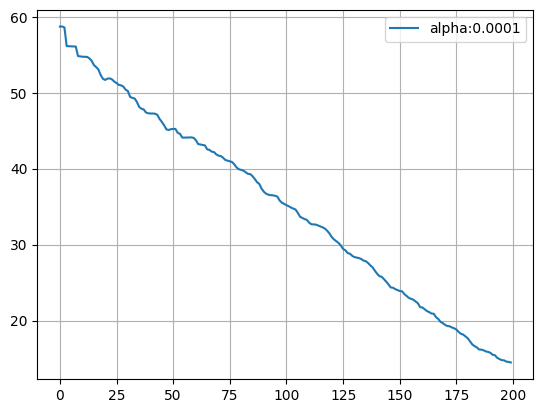

In [490]:
plt.grid()
plt.plot(err, label="alpha:"+str(round(ALPHA, 4)))
plt.legend()